# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data pandas/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

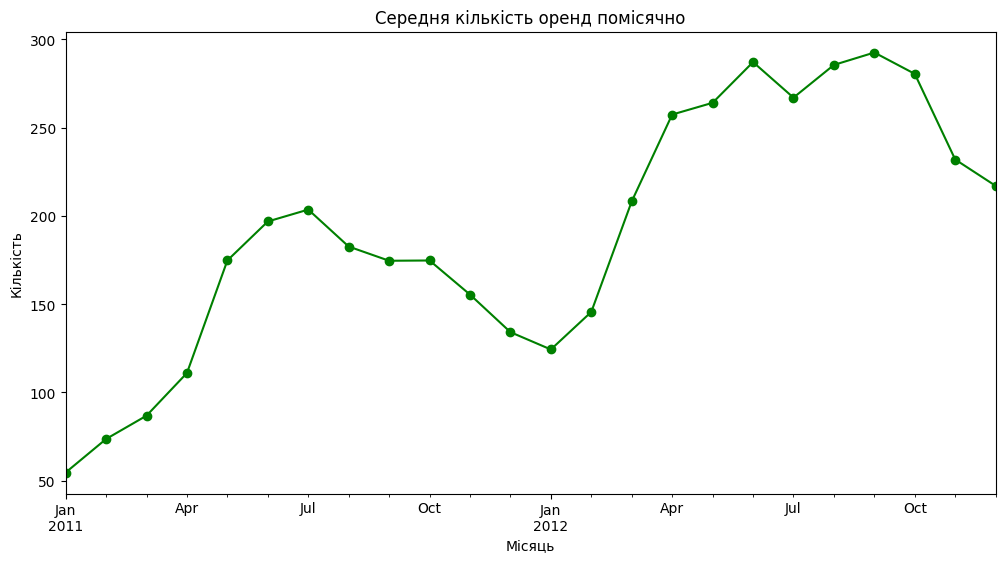

In [ ]:
monthly_avg_counts = df['count'].resample('ME').mean()
monthly_avg_counts.plot(
    figsize= (12,6),
    marker = 'o',
    title = 'Середня кількість оренд помісячно',
    color = 'green',
    xlabel = 'Місяць',
    ylabel = 'Кількість'
)
plt.show()

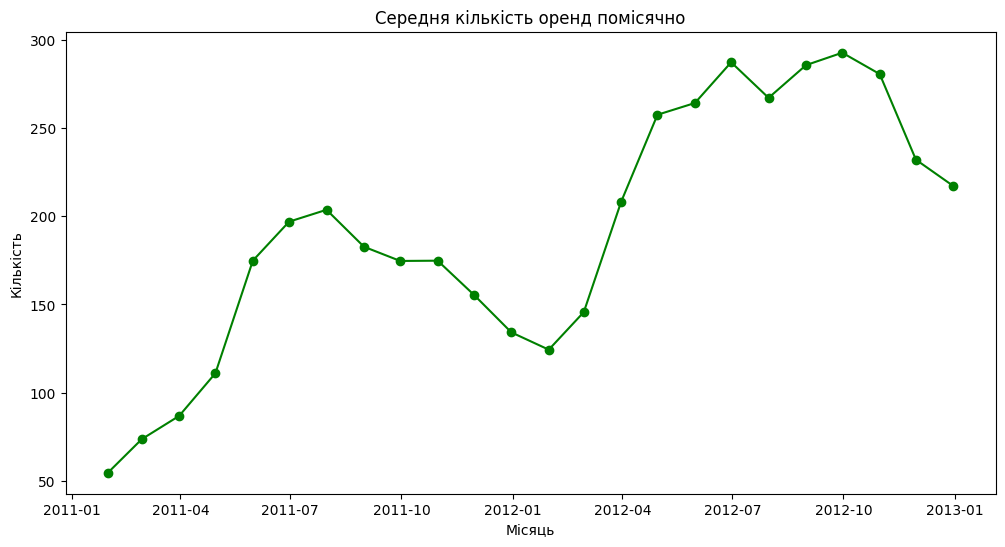

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_avg_counts, 'o-', color = 'green')
plt.title('Середня кількість оренд помісячно')
plt.xlabel('Місяць')
plt.ylabel('Кількість')
plt.show()

Обидва графіки відображають однакові дані. Відрізняються позначення місяців на осі OX. А також при використанні Matplotlib графік не щільно розташований відносно координат.
Мені більше подобається графік із використанням Matplotlib, оскільки він дає більше можливостей для налаштування та виглядає більш гнучким з точки зору подальшого оформлення

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [ ]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень2

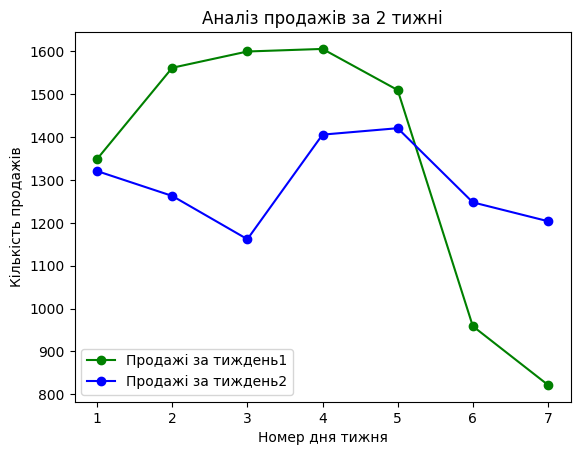

In [ ]:
plt.plot(days, sales_week1, label= 'Продажі за тиждень1', marker='o', color = 'green')
plt.plot(days, sales_week2, label= 'Продажі за тиждень2', marker='o', color = 'blue')
plt.title('Аналіз продажів за 2 тижні')
plt.xlabel('Номер дня тижня')
plt.ylabel('Кількість продажів')
plt.legend()
plt.show()

1. Судячи з графіка, другий тиждень виглядає стабільнішим, оскільки коливання продажів протягом днів є менш різкими.
2. Так. Для оцінки стабільності можна використати стандартне відхилення

In [ ]:
std_week1 = np.std(sales_week1)
std_week2 = np.std(sales_week2)

print("Стандартне відхилення 1 тиждень:", std_week1)
print("Стандартне відхилення 2 тиждень:", std_week2)

Стандартне відхилення 1 тиждень: 299.99857142517004
Стандартне відхилення 2 тиждень: 90.9060964256355


У другого тижня стандартне відхилення менше, що підтверджує його більшу стабільність

## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

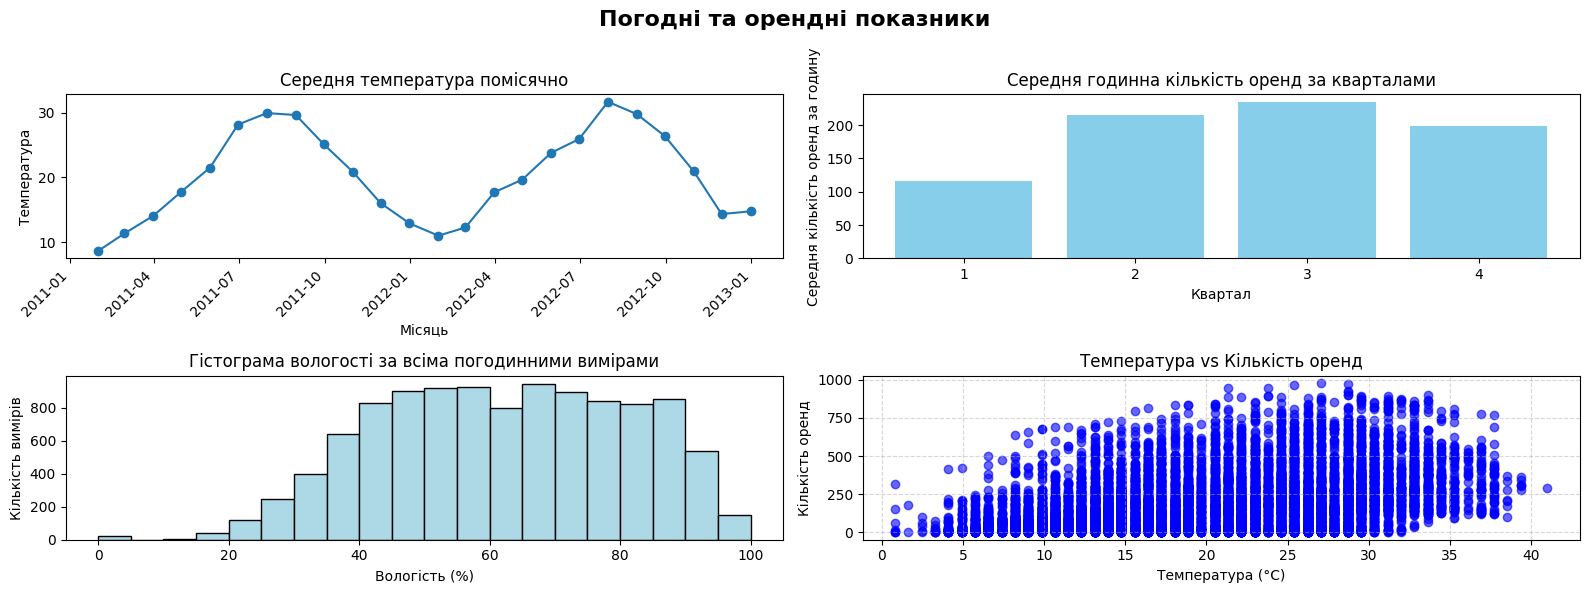

In [ ]:
#import matplotlib.dates as mdates
plt.figure(figsize = (16,6))

#Графік 1
monthly_avg_temperature = df['temp'].resample('ME').mean()
plt.subplot(2, 2, 1)
plt.plot(monthly_avg_temperature.index,monthly_avg_temperature,'o-')
plt.title('Середня температура помісячно')
plt.xlabel('Місяць')
plt.ylabel('Температура')
plt.xticks(rotation=45, ha='right')
#plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
#plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))

#Графік 2
quarterly_avg = df.groupby('season')['count'].mean()
plt.subplot(2, 2, 2)
plt.bar(quarterly_avg.index, quarterly_avg.values, color='skyblue')
plt.title('Середня годинна кількість оренд за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Середня кількість оренд за годину')
plt.xticks(quarterly_avg.index)

#Графік 3
humidity_data = df['humidity']
plt.subplot(2, 2, 3)
plt.hist(humidity_data, bins=20, color='lightblue', edgecolor='black')
plt.title("Гістограма вологості за всіма погодинними вимірами")
plt.xlabel("Вологість (%)")
plt.ylabel("Кількість вимірів")

#Графік 4
x = df['temp']
y = df['count']
plt.subplot(2, 2, 4)
plt.scatter(x, y, alpha=0.6, color='blue')
plt.title("Температура vs Кількість оренд")
plt.xlabel("Температура (°C)")
plt.ylabel("Кількість оренд")
plt.grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Погодні та орендні показники", fontsize=16, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()





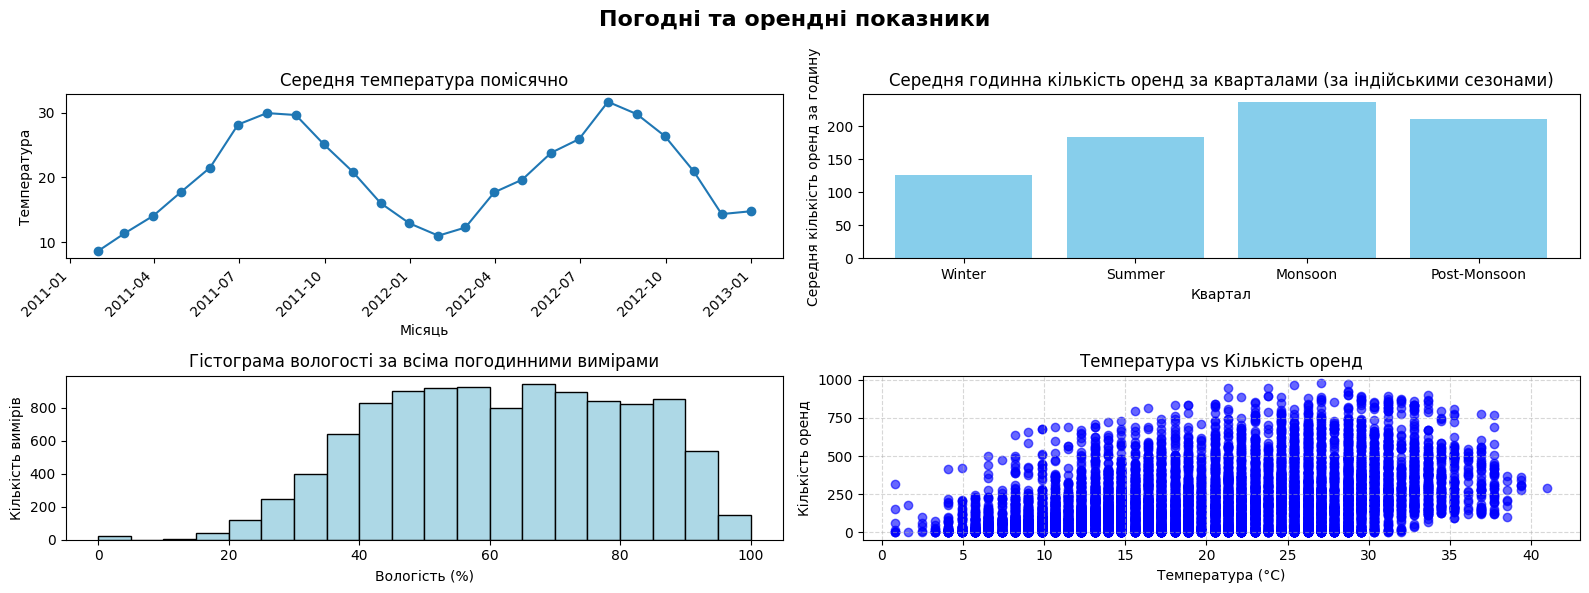

In [ ]:
def map_indian_season(month):
    if month in [12, 1, 2]:
        return 1   # Winter
    elif month in [3, 4, 5]:
        return 2   # Summer
    elif month in [6, 7, 8, 9]:
        return 3   # Monsoon
    else:  # 10, 11
        return 4   # Post-monsoon

df['weather_season_india'] = df['month'].apply(map_indian_season)
india_season_names = {
    1: 'Winter',
    2: 'Summer',
    3: 'Monsoon',
    4: 'Post-Monsoon'
}

plt.figure(figsize = (16,6))

#Графік 1
monthly_avg_temperature = df['temp'].resample('ME').mean()
plt.subplot(2, 2, 1)
plt.plot(monthly_avg_temperature.index,monthly_avg_temperature,'o-')
plt.title('Середня температура помісячно')
plt.xlabel('Місяць')
plt.ylabel('Температура')
plt.xticks(rotation=45, ha='right')


#Графік 2
quarterly_avg = df.groupby('weather_season_india')['count'].mean()
plt.subplot(2, 2, 2)
plt.bar(quarterly_avg.index, quarterly_avg.values, color='skyblue')
plt.title('Середня годинна кількість оренд за кварталами (за індійськими сезонами)')
plt.xlabel('Квартал')
plt.ylabel('Середня кількість оренд за годину')
plt.xticks(quarterly_avg.index, [india_season_names[q] for q in quarterly_avg.index])

#Графік 3
humidity_data = df['humidity']
plt.subplot(2, 2, 3)
plt.hist(humidity_data, bins=20, color='lightblue', edgecolor='black')
plt.title("Гістограма вологості за всіма погодинними вимірами")
plt.xlabel("Вологість (%)")
plt.ylabel("Кількість вимірів")

#Графік 4
x = df['temp']
y = df['count']
plt.subplot(2, 2, 4)
plt.scatter(x, y, alpha=0.6, color='blue')
plt.title("Температура vs Кількість оренд")
plt.xlabel("Температура (°C)")
plt.ylabel("Кількість оренд")
plt.grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Погодні та орендні показники", fontsize=16, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

/tmp/ipython-input-246/1060680578.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0,0].set_xticklabels(ax[0,0].get_xticklabels(), rotation=45, ha='right')


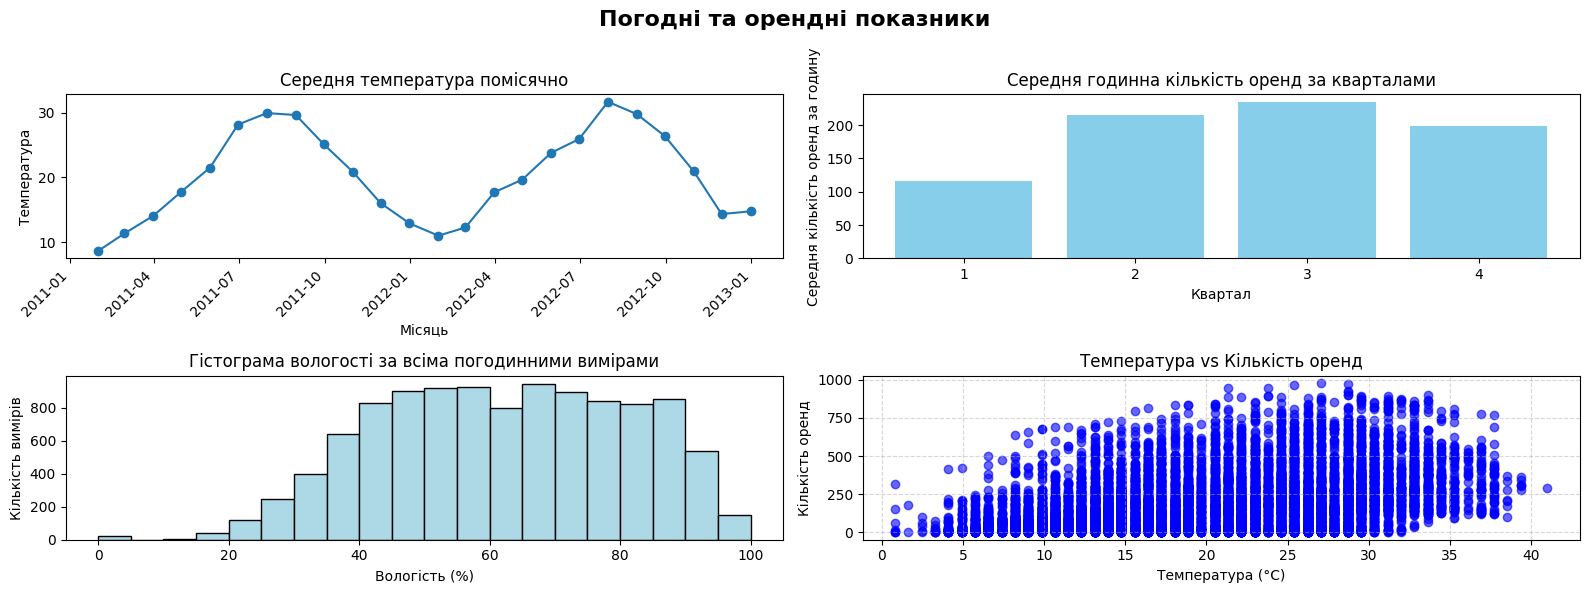

In [ ]:
#import matplotlib.dates as mdates
fig, ax = plt.subplots(2, 2, figsize=(16, 6))

#Графік 1
monthly_avg_temperature = df['temp'].resample('ME').mean()
ax[0, 0].plot(monthly_avg_temperature.index,monthly_avg_temperature,'o-')
ax[0, 0].set_title('Середня температура помісячно')
ax[0, 0].set_xlabel('Місяць')
ax[0, 0].set_ylabel('Температура')
#ax[0,0].xaxis.set_major_locator(mdates.MonthLocator())
#ax[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
#plt.setp(ax[0,0].get_xticklabels(), rotation=45, ha='right')
ax[0,0].set_xticklabels(ax[0,0].get_xticklabels(), rotation=45, ha='right')


#Графік 2
quarterly_avg = df.groupby('season')['count'].mean()
ax[0, 1].bar(quarterly_avg.index, quarterly_avg.values, color='skyblue')
ax[0, 1].set_title('Середня годинна кількість оренд за кварталами')
ax[0, 1].set_xlabel('Квартал')
ax[0, 1].set_ylabel('Середня кількість оренд за годину')
ax[0, 1].set_xticks(quarterly_avg.index)

#Графік 3
humidity_data = df['humidity']
ax[1, 0].hist(humidity_data, bins=20, color='lightblue', edgecolor='black')
ax[1, 0].set_title("Гістограма вологості за всіма погодинними вимірами")
ax[1, 0].set_xlabel("Вологість (%)")
ax[1, 0].set_ylabel("Кількість вимірів")

#Графік 4
x = df['temp']
y = df['count']
ax[1, 1].scatter(x, y, alpha=0.6, color='blue')
ax[1, 1].set_title("Температура vs Кількість оренд")
ax[1, 1].set_xlabel("Температура (°C)")
ax[1, 1].set_ylabel("Кількість оренд")
ax[1, 1].grid(True, linestyle='--', alpha=0.5)

fig.suptitle("Погодні та орендні показники", fontsize=16, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

plt.subplot() створює графіки по черзі через глобальний об’єкт plt, і важко керувати окремими підграфіками.
plt.subplots() повертає об’єкти осей ax, що дозволяє легко змінювати кожен графік окремо та робить код гнучкішим і чистішим

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

In [ ]:
import matplotlib.dates as mdates

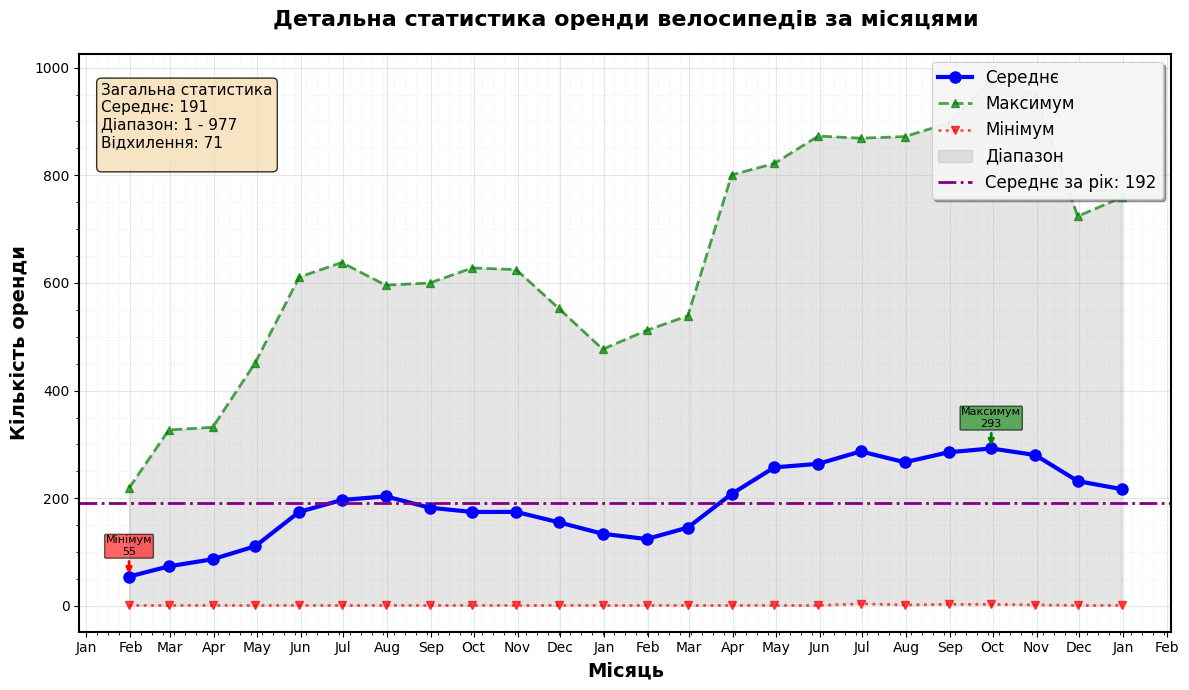

In [95]:
monthly_avg_counts = df['count'].resample('ME').agg(['mean', 'max', 'min'])
fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(monthly_avg_counts.index, monthly_avg_counts['mean'], 'b-o', linewidth=3,
        label='Середнє', markersize=8)
ax.plot(monthly_avg_counts.index, monthly_avg_counts['max'], 'g--^', linewidth=2,
        label='Максимум', markersize=6, alpha=0.7)
ax.plot(monthly_avg_counts.index, monthly_avg_counts['min'], 'r:v', linewidth=2,
        label='Мінімум', markersize=6, alpha=0.7)

ax.fill_between(monthly_avg_counts.index, monthly_avg_counts['min'], monthly_avg_counts['max'],
                alpha=0.2, color='gray', label='Діапазон')

max_idx = monthly_avg_counts['mean'].idxmax()
max_val = monthly_avg_counts['mean'].max()
ax.annotate(f'Максимум\n{max_val:.0f}',
            xy=(max_idx, max_val), xytext=(max_idx, max_val + 40),
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            fontsize=8, ha='center',
            bbox=dict(boxstyle="round,pad=0.1", facecolor='green', alpha=0.6))

min_idx = monthly_avg_counts['mean'].idxmin()
min_val = monthly_avg_counts['mean'].min()
ax.annotate(f'Мінімум\n{min_val:.0f}',
            xy=(min_idx, min_val), xytext=(min_idx, min_val + 40),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=8, ha='center',
            bbox=dict(boxstyle="round,pad=0.1", facecolor='red', alpha=0.6))

ax.set_xlabel('Місяць', fontsize=14, fontweight='bold')
ax.set_ylabel('Кількість оренди', fontsize=14, fontweight='bold')
ax.set_title('Детальна статистика оренди велосипедів за місяцями',
             fontsize=16, fontweight='bold', pad=20)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())

ax.grid(True, which='major', linestyle='-', alpha=0.3)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)
ax.minorticks_on()


overall_mean = df['count'].mean()
ax.axhline(y=overall_mean, color='purple', linestyle='-.', linewidth=2,
           label=f'Середнє за рік: {overall_mean:.0f}')

ax.legend(loc='upper right', fontsize=12, frameon=True, shadow=True,
          fancybox=True, framealpha=0.9)

textstr = f'Загальна статистика\n'
textstr += f'Середнє: {monthly_avg_counts["mean"].mean():.0f}\n'
textstr += f'Діапазон: {monthly_avg_counts["min"].min():.0f} - {monthly_avg_counts["max"].max():.0f}\n'
textstr += f'Відхилення: {monthly_avg_counts["mean"].std():.0f}\n'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()

1. Анотації на графіку допомагають виділити важливі точки, наприклад мінімум чи максимум, щоб їх легко було побачити і зрозуміти
2. fill_between() дозволяє показати діапазон значень між двома кривими, наочно відображаючи розмах або варіацію даних
3. Текстовий блок на графіку дає швидкий огляд ключових статистик, щоб не треба було шукати їх у таблиці, і допомагає швидко інтерпретувати дані